In [ ]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split

from category_encoders import TargetEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

from sklearn.linear_model import Ridge, Lasso

from sklearn.utils.validation import check_is_fitted
from sklearn.base import BaseEstimator, RegressorMixin, TransformerMixin
import statsmodels.api as sm

from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.model_selection import cross_val_predict

from sklearn.model_selection import GridSearchCV, KFold
import matplotlib.pyplot as plt

import shap
from sklearn.feature_selection import RFE, RFECV

# SET UP

In [25]:
linear_reg = LinearRegression()
tree_reg = DecisionTreeRegressor()
forest_reg = RandomForestRegressor()
svr_reg = SVR()

In [26]:
class TargetEncoderWrapper(BaseEstimator, TransformerMixin):
    def __init__(self, cols=None):
        self.cols = cols
        self.encoder = TargetEncoder(cols=cols)

    def fit(self, X, y):
        self.encoder.fit(X, y)
        return self

    def transform(self, X):
        return self.encoder.transform(X)

In [27]:
class StatsmodelsOLS(BaseEstimator, RegressorMixin):
    def fit(self, X, y):
        X = sm.add_constant(X)
        self.model_ = sm.OLS(y, X).fit()
        self.X_columns_ = X.columns if hasattr(X, 'columns') else None
        return self

    def predict(self, X):
        X = sm.add_constant(X)
        return self.model_.predict(X)

    def summary(self):
        return self.model_.summary()

In [28]:
df = pd.read_csv(r"C:\Users\jfurs\@Python\OpenClassrooms\DS\P4\energy_use\df_energy_use.csv")
df = df.drop(columns=["SteamUse(kBtu)", "Electricity(kBtu)", "NaturalGas(kBtu)"])

In [29]:
df.head()

,NumberofBuildings,PropertyGFATotal,PropertyGFABuilding(s),SiteEnergyUse(kBtu),Electricity_usage,NaturalGas_usage,Steam_usage,building_age_category,building_height_category,ratio_parking,PrimaryPropertyType
0,1.0,88434,88434,7226362.5,1,1,1,1900-1939,11-30,0.000000,Hotel
1,1.0,103566,88502,8387933.0,1,1,1,1980-1999,11-30,0.145453,Hotel
2,1.0,956110,759392,72587024.0,1,1,1,1960-1979,31+,0.205748,Hotel
3,1.0,61320,61320,6794584.0,1,1,1,1900-1939,6-10,0.000000,Hotel
4,1.0,175580,113580,14172606.0,1,1,1,1980-1999,11-30,0.353115,Hotel


In [30]:
X = df.drop('SiteEnergyUse(kBtu)', axis=1).copy()
y = df['SiteEnergyUse(kBtu)'].copy()

y = np.log(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [32]:
np.mean(y)

np.float64(14.92838725471784)

In [8]:
tgt_enc_features = ["PrimaryPropertyType"]
cat_features = ['building_age_category', 'building_height_category']
to_scale_features = ["PropertyGFABuilding(s)","PropertyGFATotal"]

tgt_enc_transformer = Pipeline([
    ("tgt_enc", TargetEncoderWrapper(cols=tgt_enc_features))
])

numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
    ])

categorical_transformer = Pipeline([
    ('encoder', OrdinalEncoder())
    ])

preprocessor = ColumnTransformer([
    ("t_enc", tgt_enc_transformer, tgt_enc_features), 
    ('num', numeric_transformer, to_scale_features),
    ('cat', categorical_transformer, cat_features),
    ], remainder='passthrough')

# NON LINEAR PREDICTIONS

In [9]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Tracking
nl_cv_scores = {}
nl_best_model = None
nl_best_score = -np.inf
nl_best_params = None
nl_best_model_name = ""

In [10]:
non_linear_model_configs = [
    {
        "name": "SVR_rbf",
        "estimator": SVR(kernel='rbf'),
        "param_grid": {
            "regressor__C": [0.1, 1, 10, 100],
            "regressor__gamma": ['scale', 'auto', 0.01, 0.1, 1],
            "regressor__epsilon": [0.01, 0.1, 0.2, 0.5]
        }
    },
    {
        "name": "XGBRegressor",
        "estimator": XGBRegressor(random_state=42, verbosity=0),
        "param_grid": {
            "regressor__n_estimators": [100, 200, 300],
            "regressor__max_depth": [3, 5, 7, 10],
            "regressor__learning_rate": [0.01, 0.05, 0.1, 0.2],
            "regressor__subsample": [0.6, 0.8, 1.0],
            "regressor__colsample_bytree": [0.6, 0.8, 1.0],
            "regressor__gamma": [0, 0.1, 0.3, 1]
        }
    },
    {
        "name": "RandomForestRegressor",
        "estimator": RandomForestRegressor(random_state=42),
        "param_grid": {
            "regressor__n_estimators": [50, 100, 200, 300],
            "regressor__max_depth": [5, 10, 15, 20, None],
            "regressor__min_samples_split": [2, 5, 10],
            "regressor__min_samples_leaf": [1, 2, 4],
            "regressor__max_features": ['sqrt', 'log2', None]
        }
    }
]

In [11]:
for config in non_linear_model_configs:
    print(f"\n============= {config['name']} ===================")

    # Build pipeline
    full_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', config["estimator"])
    ])

    # GridSearchCV
    grid = GridSearchCV(
        full_pipeline,
        param_grid=config["param_grid"],
        cv=cv,
        scoring='r2', # neg_mean_squared_error
        n_jobs=-1
    )

    grid.fit(X_train, y_train)
    mean_score = grid.best_score_

    # Use the best estimator to get cross-validated predictions
    best_estimator = grid.best_estimator_
    y_pred = cross_val_predict(best_estimator, X_train, y_train, cv=cv, n_jobs=-1)
    
    rmse = np.sqrt(root_mean_squared_error(y_train, y_pred))

    print(f"Best R²: {mean_score:.4f}")
    print(f"Best Params: {grid.best_params_}")
    print(f"RMSE: {rmse:.4f}")
    
    nl_cv_scores[config["name"]] = grid.cv_results_['mean_test_score']

    if mean_score > nl_best_score:
        nl_best_score = mean_score
        nl_best_model = grid.best_estimator_
        nl_best_params = grid.best_params_
        nl_best_model_name = config["name"]


============= SVR_rbf ===================
Best R²: 0.6779
Best Params: {'regressor__C': 100, 'regressor__epsilon': 0.2, 'regressor__gamma': 0.01}
RMSE: 0.8559

============= XGBRegressor ===================
Best R²: 0.7189
Best Params: {'regressor__colsample_bytree': 1.0, 'regressor__gamma': 1, 'regressor__learning_rate': 0.1, 'regressor__max_depth': 3, 'regressor__n_estimators': 100, 'regressor__subsample': 0.8}
RMSE: 0.8271

============= RandomForestRegressor ===================
Best R²: 0.7072
Best Params: {'regressor__max_depth': 10, 'regressor__max_features': 'sqrt', 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 10, 'regressor__n_estimators': 300}
RMSE: 0.8357


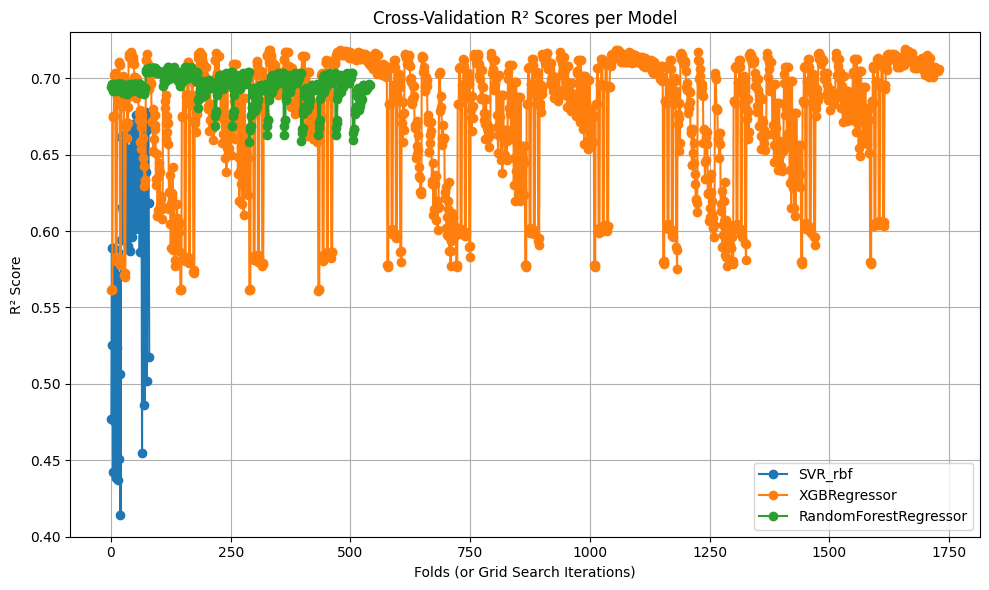


🏆 Best Model:
Model: XGBRegressor
Mean CV R²: 0.7189
Best Hyperparameters: {'regressor__colsample_bytree': 1.0, 'regressor__gamma': 1, 'regressor__learning_rate': 0.1, 'regressor__max_depth': 3, 'regressor__n_estimators': 100, 'regressor__subsample': 0.8}


In [12]:
# Plot CV Scores
plt.figure(figsize=(10, 6))
for name, scores in nl_cv_scores.items():
    x = range(1, len(scores) + 1) 
    if isinstance(scores, list):
        plt.plot(x, scores, label=f"{name} (manual)", marker='o')
    else:
        plt.plot(x, scores, label=f"{name}", marker='o')

plt.ylim(0.4, 0.73)
plt.title("Cross-Validation R² Scores per Model")
plt.xlabel("Folds (or Grid Search Iterations)")
plt.ylabel("R² Score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print the best model summary
print("\n🏆 Best Model:")
print(f"Model: {nl_best_model_name}")
print(f"Mean CV R²: {nl_best_score:.4f}")
if nl_best_params:
    print("Best Hyperparameters:", nl_best_params)

# LINEAR PREDICTIONS

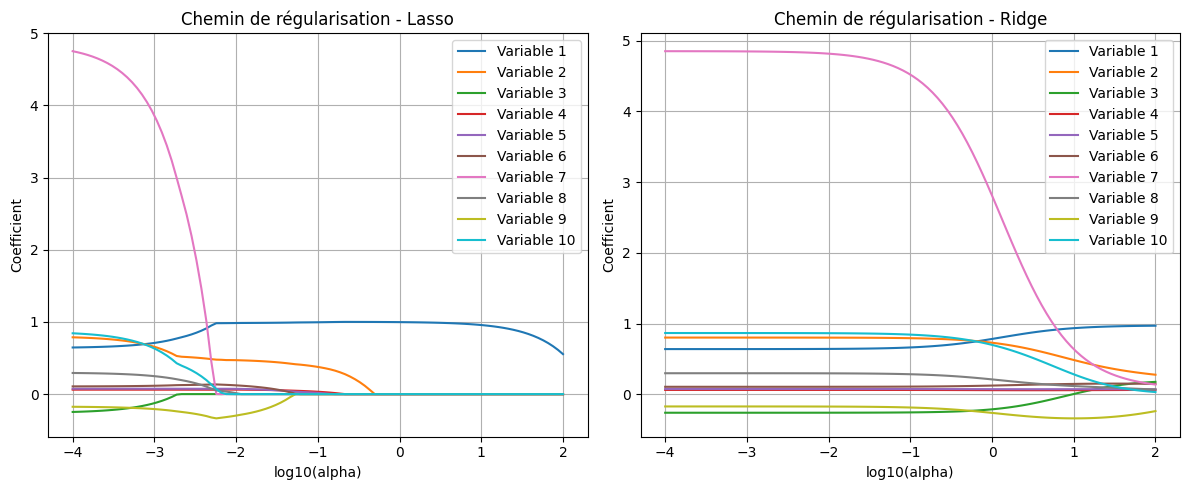

In [13]:
X_train_scaled = preprocessor.fit_transform(X_train, y_train)

alphas = np.logspace(-4, 2, 100)

def plot_two_regularization_paths(model_classes, model_names, X, y):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 ligne, 2 colonnes
    
    for ax, model_class, model_name in zip(axes, model_classes, model_names):
        coefs = []
        for alpha in alphas:
            model = model_class(alpha=alpha, fit_intercept=False, max_iter=10000)
            model.fit(X, y)
            coefs.append(model.coef_)

        coefs = np.array(coefs)
        for i in range(coefs.shape[1]):
            ax.plot(np.log10(alphas), coefs[:, i], label=f'Variable {i+1}')
        ax.set_xlabel('log10(alpha)')
        ax.set_ylabel('Coefficient')
        ax.set_title(f'Chemin de régularisation - {model_name}')
        ax.grid(True)
        ax.legend()
    
    plt.tight_layout()
    plt.show()

plot_two_regularization_paths([Lasso, Ridge], ["Lasso", "Ridge"], X_train_scaled, y_train)

In [14]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

l_cv_scores = {}
l_best_model = None
l_best_score = -np.inf
l_best_params = None
l_best_model_name = ""

In [ ]:
linear_model_configs = [
    {
        "name": "Ridge",
        "estimator": Ridge(),
        "param_grid": {
            "regressor__alpha": np.logspace(-3, 3, 10),
            "regressor__solver": ['auto', 'svd', 'cholesky', 'lsqr', 'sag', 'saga'],
            "regressor__fit_intercept": [True, False]
        }
    },
    {
        "name": "Lasso",
        "estimator": Lasso(max_iter=10000),
        "param_grid": {
            "regressor__alpha": np.logspace(-4, 1, 20),
            "regressor__fit_intercept": [True, False],
            "regressor__selection": ['cyclic', 'random']
        }
    },
    {
        "name": "SVR_linear",
        "estimator": SVR(kernel='linear'),
        "param_grid": {
            "regressor__C": [0.01, 0.1, 1, 10, 100],
            "regressor__epsilon": [0.01, 0.1, 0.2, 0.5]
        }
    }
]

In [16]:
for config in linear_model_configs:
    print(f"\n============= {config['name']} ===================")

    full_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', config["estimator"])
    ])

    # GridSearchCV
    grid = GridSearchCV(
        full_pipeline,
        param_grid=config["param_grid"],
        cv=cv,
        scoring='r2', # neg_mean_squared_error
        n_jobs=-1
    )

    grid.fit(X_train, y_train)
    mean_score = grid.best_score_

    # Use the best estimator to get cross-validated predictions
    best_estimator = grid.best_estimator_
    y_pred = cross_val_predict(best_estimator, X_train, y_train, cv=cv, n_jobs=-1)
    
    rmse = np.sqrt(root_mean_squared_error(y_train, y_pred))

    print(f"Best R²: {mean_score:.4f}")
    print(f"Best Params: {grid.best_params_}")
    print(f"RMSE: {rmse:.4f}")
    
    l_cv_scores[config["name"]] = grid.cv_results_['mean_test_score']

    if mean_score > l_best_score:
        l_best_score = mean_score
        l_best_model = grid.best_estimator_
        l_best_params = grid.best_params_
        l_best_model_name = config["name"]


============= Ridge ===================
Best R²: 0.5393
Best Params: {'regressor__alpha': np.float64(2.154434690031882), 'regressor__fit_intercept': True, 'regressor__solver': 'lsqr'}
RMSE: 0.9369

============= Lasso ===================
Best R²: 0.5392
Best Params: {'regressor__alpha': np.float64(0.0001), 'regressor__fit_intercept': False, 'regressor__selection': 'random'}
RMSE: 0.9372

============= SVR_linear ===================
Best R²: 0.5348
Best Params: {'regressor__C': 0.1, 'regressor__epsilon': 0.5}
RMSE: 0.9395


In [17]:
X_train_trans = preprocessor.fit_transform(X_train, y_train)

X_train_trans_const = sm.add_constant(X_train_trans)

# Fit OLS model
linear_model = sm.OLS(y_train, X_train_trans_const).fit()

# Print summary
print(linear_model.summary())

                             OLS Regression Results                            
Dep. Variable:     SiteEnergyUse(kBtu)   R-squared:                       0.569
Model:                             OLS   Adj. R-squared:                  0.566
Method:                  Least Squares   F-statistic:                     177.4
Date:                 Thu, 27 Nov 2025   Prob (F-statistic):          6.33e-214
Time:                         14:34:30   Log-Likelihood:                -1539.4
No. Observations:                 1219   AIC:                             3099.
Df Residuals:                     1209   BIC:                             3150.
Df Model:                            9                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.6387      0.052     12.25

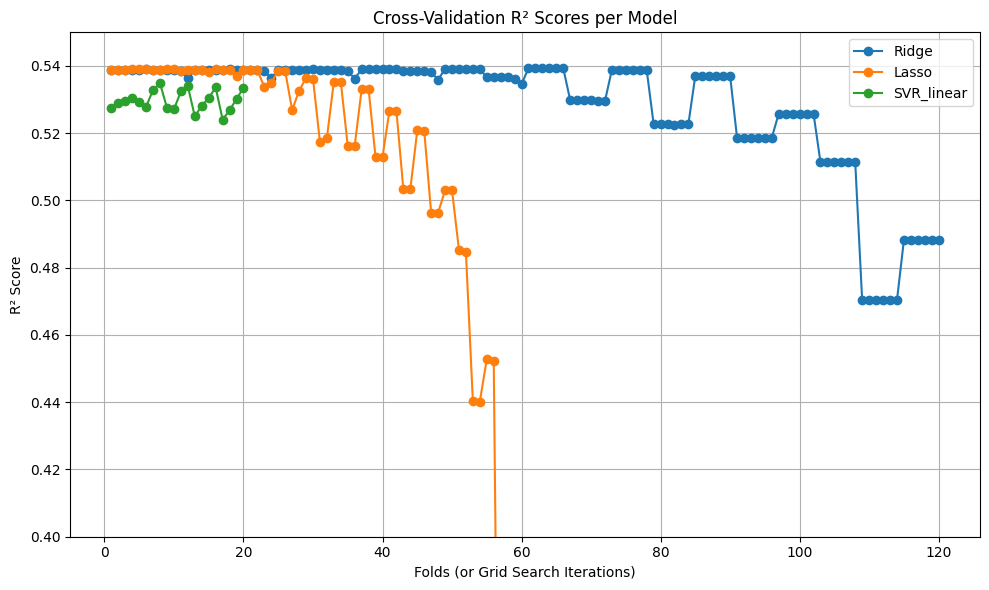


🏆 Best Model:
Model: Ridge
Mean CV R²: 0.5393
Best Hyperparameters: {'regressor__alpha': np.float64(2.154434690031882), 'regressor__fit_intercept': True, 'regressor__solver': 'lsqr'}


In [18]:
# Plot CV Scores
plt.figure(figsize=(10, 6))
for name, scores in l_cv_scores.items():
    x = range(1, len(scores) + 1) 
    if isinstance(scores, list):
        plt.plot(x, scores, label=f"{name} (manual)", marker='o')
    else:
        plt.plot(x, scores, label=f"{name}", marker='o')

plt.ylim(0.4, 0.55)
plt.title("Cross-Validation R² Scores per Model")
plt.xlabel("Folds (or Grid Search Iterations)")
plt.ylabel("R² Score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print the best model summary
print("\n🏆 Best Model:")
print(f"Model: {l_best_model_name}")
print(f"Mean CV R²: {l_best_score:.4f}")
if l_best_params:
    print("Best Hyperparameters:", l_best_params)

# RESULTS

In [19]:
check_is_fitted(nl_best_model)

nl_best_model.fit(X_train, y_train)
y_pred = nl_best_model.predict(X_test)

rmse_bm = root_mean_squared_error(y_test, y_pred)
r2_bm = r2_score(y_test, y_pred)

print(f"R² score on the test set using the best model ({nl_best_model_name}): {r2_bm:.4f}")
print(f"RMSE score on the test set using the best model ({nl_best_model_name}): {rmse_bm:.4f}", "\n")

R² score on the test set using the best model (XGBRegressor): 0.6560
RMSE score on the test set using the best model (XGBRegressor): 0.7149 



c:\Users\jfurs\anaconda3\envs\labo_313\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [20]:
nl_best_model

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('t_enc', ...), ('num', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


c:\Users\jfurs\anaconda3\envs\labo_313\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


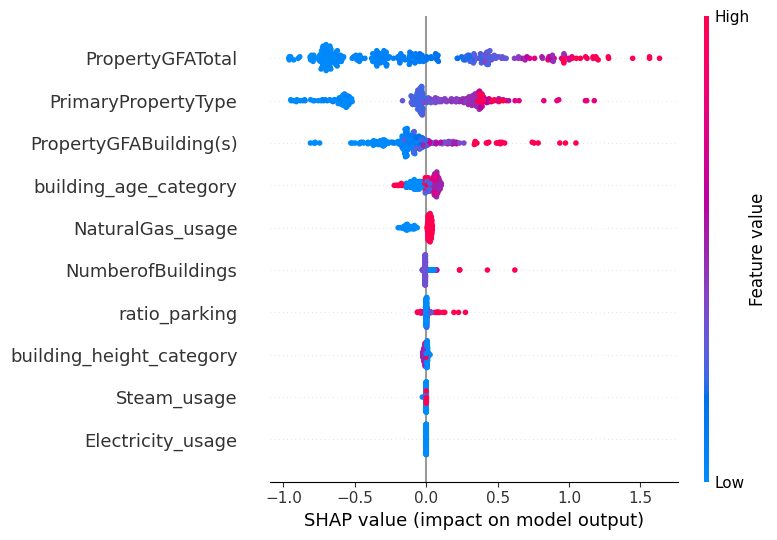

In [21]:
feature_names = ["PrimaryPropertyType", "PropertyGFABuilding(s)", "PropertyGFATotal", "building_age_category", "building_height_category",
                  "NumberofBuildings", "Electricity_usage", "NaturalGas_usage", "Steam_usage", "ratio_parking"]

# Get transformed data
X_transformed = nl_best_model[:-1].transform(X_test)

# Get the trained XGBRegressor from pipeline
xgb_model = nl_best_model.named_steps['regressor']  # adjust name if different

# TreeExplainer for XGBoost
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_transformed)

# Plot summary
shap.summary_plot(shap_values, X_transformed, feature_names=feature_names)

# RFE

In [ ]:
rfe = RFE(estimator=xgb_model, n_features_to_select=5, step=1)

X_train_trans = preprocessor.fit_transform(X_train, y_train)
X_test_trans = preprocessor.transform(X_test)

rfe.fit(X_train_trans, y_train)

print("Selected features mask:", rfe.support_)
print("Ranking of features:", rfe.ranking_)

score = rfe.score(X_test_trans, y_test)
print("Test R²:", score)

In [ ]:
rfecv = RFECV(estimator=xgb_model, step=1, cv=5, scoring='r2')
rfecv.fit(X_train_trans, y_train)

plt.figure(figsize=(10,6))
plt.plot(range(1, len(rfecv.grid_scores_) + 1), rfecv.grid_scores_)
plt.xlabel("Nombre de features gardées")
plt.ylabel("Cross-validated R² score")
plt.title("R² vs Nombre de features (RFECV)")
plt.show()